#  Использование предобученных моделей для классификации изображений

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы: 
* Deep Learning with PyTorch (2020) Авторы: Eli Stevens, Luca Antiga, Thomas Viehmann 
* https://pytorch.org/vision/0.16/transforms.html#v2-api-reference-recommended
* https://pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html
* https://pytorch.org/vision/stable/models.html
* https://albumentations.ai/docs/getting_started/image_augmentation/

## Задачи для совместного разбора

1\. Загрузите предобученную модель из `torchvision`. Познакомьтесь с ее архитектурой. Заморозьте веса нескольких слоев.

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Используя реализацию из `torchvision`, cоздайте модель `vgg16` и загрузите предобученные веса `IMAGENET1K_V1`. Выведите на экран структуру модели, количество слоев и количество настраиваемых (`requires_grad==True`) параметров модели. 

- [ ] Проверено на семинаре

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from torchvision import datasets, transforms
import random
import os
from torchvision import models
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torch.distributed as dist
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import time

In [4]:
vgg16_model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

print("Model structure:\n", vgg16_model)

trainable_params = sum(p.requires_grad for p in vgg16_model.parameters())
print("Number of layers:", trainable_params)

total_params = sum(p.numel() for p in vgg16_model.parameters() if p.requires_grad)
print("Total number of trainable parameters:", total_params)

Model structure:
 VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, pad

<p class="task" id="2"></p>

2\. Создайте датасет `CatBreeds` на основе данных из архива `cat_breeds_4.zip`. Разбейте датасет на обучающее и тестовое множество в соотношении 80 на 20%. 

К обучающему датасету примените следующее преобразование: приведите картинки к размеру 256x256, затем обрежьте по центру с размером 224х224, затем переведите изображения в тензор и нормализуйте значения интенсивности пикселей (`mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)`).

К тестовому датасету примените преобразование `VGG16_Weights.IMAGENET1K_V1.transforms`.

- [ ] Проверено на семинаре

In [5]:
data_folder = 'cat_breeds_4'

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

In [7]:
vgg16_weights = models.VGG16_Weights.IMAGENET1K_V1
test_transform = vgg16_weights.transforms()

In [9]:
full_dataset = datasets.ImageFolder(root=data_folder)

In [11]:
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

In [12]:
train_dataset.dataset.transform = train_transform
test_dataset.dataset.transform = test_transform

In [14]:
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

<p class="task" id="3"></p>

3\. Заморозьте все веса модели из предыдущего задания. Замените последний слой `Linear` классификатора на новый слой, соответствующий задаче. После изменения последнего слоя выведите на экран количество настраиваемых (`requires_grad==True`) параметров модели. Решите задачу, используя модель с замороженными весами и изменнным последним слоем. 

Постройте график изменения значения функции потерь на обучающем множестве в зависимости от номера эпохи, графики изменения метрики accuracy на обучающем и тестовом множестве в зависимости от эпохи. Выведите на экран итоговое значение метрики accuracy на обучающем и тестовом множестве. 

- [ ] Проверено на семинаре

In [16]:
vgg16_model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

In [17]:
for param in vgg16_model.parameters():
    param.requires_grad = False


In [18]:
num_classes = 4
vgg16_model.classifier[6] = nn.Linear(vgg16_model.classifier[6].in_features, num_classes)


In [19]:
trainable_params = sum(p.requires_grad for p in vgg16_model.parameters())
print("Number of trainable parameters:", trainable_params)

Number of trainable parameters: 2


In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vgg16_model.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [21]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg16_model.classifier[6].parameters(), lr=0.001)

In [30]:
num_epochs = 20
train_losses = []
train_accuracies = []
test_accuracies = []

In [31]:
def compute_accuracy(loader, model):
    correct = 0
    total = 0
    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

In [32]:
for epoch in range(num_epochs):
    vgg16_model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = vgg16_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    train_accuracy = compute_accuracy(train_loader, vgg16_model)
    test_accuracy = compute_accuracy(test_loader, vgg16_model)
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}")


Epoch [1/20], Loss: 0.4168, Train Accuracy: 0.8856, Test Accuracy: 0.7963
Epoch [2/20], Loss: 0.4215, Train Accuracy: 0.8838, Test Accuracy: 0.8063
Epoch [3/20], Loss: 0.3993, Train Accuracy: 0.8903, Test Accuracy: 0.8075
Epoch [4/20], Loss: 0.3901, Train Accuracy: 0.8891, Test Accuracy: 0.8000
Epoch [5/20], Loss: 0.4013, Train Accuracy: 0.8950, Test Accuracy: 0.8050
Epoch [6/20], Loss: 0.3951, Train Accuracy: 0.8878, Test Accuracy: 0.8025
Epoch [7/20], Loss: 0.3817, Train Accuracy: 0.8888, Test Accuracy: 0.7975
Epoch [8/20], Loss: 0.3878, Train Accuracy: 0.8972, Test Accuracy: 0.8063
Epoch [9/20], Loss: 0.3711, Train Accuracy: 0.8962, Test Accuracy: 0.7937
Epoch [10/20], Loss: 0.3792, Train Accuracy: 0.8988, Test Accuracy: 0.7937
Epoch [11/20], Loss: 0.3802, Train Accuracy: 0.8994, Test Accuracy: 0.8050
Epoch [12/20], Loss: 0.3772, Train Accuracy: 0.9113, Test Accuracy: 0.8063
Epoch [13/20], Loss: 0.3742, Train Accuracy: 0.9056, Test Accuracy: 0.8037
Epoch [14/20], Loss: 0.3602, Train

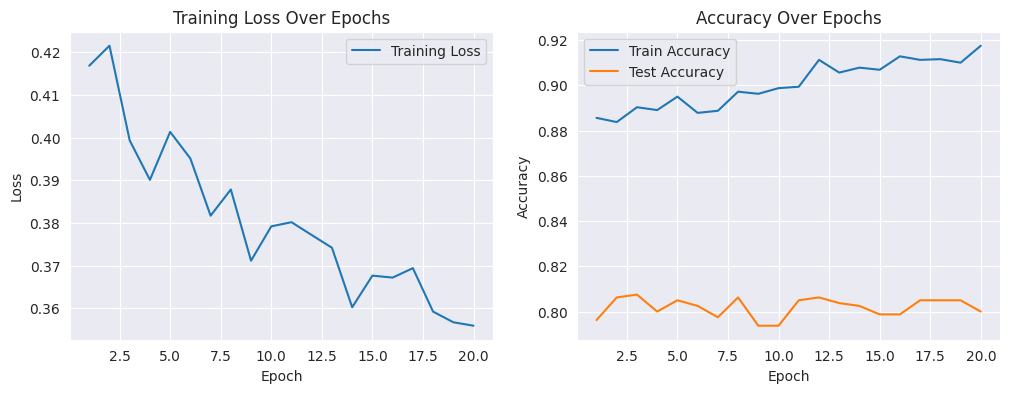

In [33]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accuracies, label='Train Accuracy')
plt.plot(range(1, num_epochs + 1), test_accuracies, label='Test Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Over Epochs")
plt.legend()
plt.show()

In [34]:
print(f"Final Train Accuracy: {train_accuracies[-1] * 100:.2f}%")
print(f"Final Test Accuracy: {test_accuracies[-1] * 100:.2f}%")


Final Train Accuracy: 91.75%
Final Test Accuracy: 80.00%


<p class="task" id="4"></p>

4\. Повторите решение предыдущей задачи, заморозив все сверточные слои, кроме последнего (слои классификатора не замораживайте). Сравните качество полученного решения и решения из предыдущей задачи, а также время, затраченное на обучения моделей. Перед началом работы создайте модель заново.

- [ ] Проверено на семинаре

In [35]:
vgg16_model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

In [36]:
for name, param in vgg16_model.features.named_parameters():
    if "29" not in name:
        param.requires_grad = False


In [38]:
num_classes = 10 
vgg16_model.classifier[6] = nn.Linear(vgg16_model.classifier[6].in_features, num_classes)

In [39]:
trainable_params = sum(p.requires_grad for p in vgg16_model.parameters())
print("Number of trainable parameters:", trainable_params)

Number of trainable parameters: 6


In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vgg16_model.to(device)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [41]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, vgg16_model.parameters()), lr=0.001)


In [42]:
num_epochs = 20
train_losses = []
train_accuracies = []
test_accuracies = []
epoch_times = []


In [44]:
for epoch in range(num_epochs):
    start_time = time.time() 

    vgg16_model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = vgg16_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    train_accuracy = compute_accuracy(train_loader, vgg16_model)
    test_accuracy = compute_accuracy(test_loader, vgg16_model)
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

    epoch_duration = time.time() - start_time
    epoch_times.append(epoch_duration)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_train_loss:.4f}, "
          f"Train Accuracy: {train_accuracy * 100:.2f}%, Test Accuracy: {test_accuracy * 100:.2f}%, "
          f"Epoch Time: {epoch_duration:.2f} sec")


Epoch [1/20], Loss: 1.9036, Train Accuracy: 78.75%, Test Accuracy: 73.50%, Epoch Time: 33.34 sec
Epoch [2/20], Loss: 0.7167, Train Accuracy: 84.31%, Test Accuracy: 75.75%, Epoch Time: 33.95 sec
Epoch [3/20], Loss: 0.4511, Train Accuracy: 87.84%, Test Accuracy: 77.75%, Epoch Time: 33.85 sec
Epoch [4/20], Loss: 0.3278, Train Accuracy: 93.56%, Test Accuracy: 78.50%, Epoch Time: 33.72 sec
Epoch [5/20], Loss: 0.2049, Train Accuracy: 96.75%, Test Accuracy: 78.88%, Epoch Time: 33.30 sec
Epoch [6/20], Loss: 0.1288, Train Accuracy: 99.12%, Test Accuracy: 78.12%, Epoch Time: 31.51 sec
Epoch [7/20], Loss: 0.0612, Train Accuracy: 99.69%, Test Accuracy: 78.88%, Epoch Time: 33.52 sec
Epoch [8/20], Loss: 0.0460, Train Accuracy: 99.84%, Test Accuracy: 75.38%, Epoch Time: 32.51 sec
Epoch [9/20], Loss: 0.0387, Train Accuracy: 99.78%, Test Accuracy: 76.50%, Epoch Time: 35.19 sec
Epoch [10/20], Loss: 0.0374, Train Accuracy: 99.88%, Test Accuracy: 78.50%, Epoch Time: 31.86 sec
Epoch [11/20], Loss: 0.0242, 

In [45]:
print(f"Final Train Accuracy: {train_accuracies[-1] * 100:.2f}%")
print(f"Final Test Accuracy: {test_accuracies[-1] * 100:.2f}%")
print(f"Average Epoch Time: {sum(epoch_times) / num_epochs:.2f} sec")

Final Train Accuracy: 99.97%
Final Test Accuracy: 76.38%
Average Epoch Time: 33.29 sec


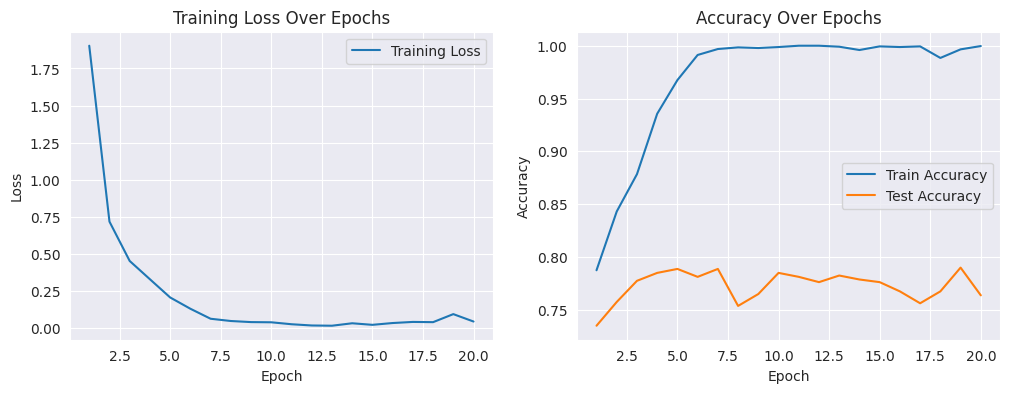

In [46]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accuracies, label='Train Accuracy')
plt.plot(range(1, num_epochs + 1), test_accuracies, label='Test Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Over Epochs")
plt.legend()
plt.show()

<p class="task" id="5"></p>

5\. Повторите решение задачи 3, расширив обучающий набор данных при помощи преобразований из `torchvision`, изменяющих изображение (повороты, изменение интенсивности пикселей, обрезание и т.д.). При оценке модели на тестовой выборке данные преобразования применяться не должны. Решение о том, сколько и каких слоев модели будет обучаться, примите самостоятельно. Перед началом работы создайте модель заново.

- [ ] Проверено на семинаре

In [47]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),               # Случайное изменение размера и обрезание до 224x224
    transforms.RandomHorizontalFlip(),               # Случайное горизонтальное отражение
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Яркость, контраст, насыщенность
    transforms.RandomRotation(20),                   # Случайный поворот на ±20 градусов
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))    # Нормализация
])

In [49]:
data_folder = 'cat_breeds_4'

In [51]:
vgg16_weights = models.VGG16_Weights.IMAGENET1K_V1
test_transform = vgg16_weights.transforms()

In [52]:
full_dataset = datasets.ImageFolder(root=data_folder)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

In [53]:
train_dataset.dataset.transform = train_transform
test_dataset.dataset.transform = test_transform

In [54]:
vgg16_model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

In [55]:
for name, param in vgg16_model.features.named_parameters():
    if "29" not in name: 
        param.requires_grad = False

In [56]:
num_classes = 4
vgg16_model.classifier[6] = nn.Linear(vgg16_model.classifier[6].in_features, num_classes)

In [58]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vgg16_model.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [59]:
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

In [61]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, vgg16_model.parameters()), lr=0.001)

In [62]:
def compute_accuracy(loader, model):
    correct = 0
    total = 0
    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

In [63]:
num_epochs = 20
train_losses = []
train_accuracies = []
test_accuracies = []

In [64]:
for epoch in range(num_epochs):
    vgg16_model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward + Backward + Optimize
        optimizer.zero_grad()
        outputs = vgg16_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    train_accuracy = compute_accuracy(train_loader, vgg16_model)
    test_accuracy = compute_accuracy(test_loader, vgg16_model)
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_train_loss:.4f}, "
          f"Train Accuracy: {train_accuracy * 100:.2f}%, Test Accuracy: {test_accuracy * 100:.2f}%")

Epoch [1/20], Loss: 1.5892, Train Accuracy: 71.16%, Test Accuracy: 66.88%
Epoch [2/20], Loss: 0.7253, Train Accuracy: 77.84%, Test Accuracy: 71.88%
Epoch [3/20], Loss: 0.4944, Train Accuracy: 89.41%, Test Accuracy: 76.00%
Epoch [4/20], Loss: 0.3475, Train Accuracy: 93.03%, Test Accuracy: 75.88%
Epoch [5/20], Loss: 0.2234, Train Accuracy: 95.38%, Test Accuracy: 78.75%
Epoch [6/20], Loss: 0.1346, Train Accuracy: 96.16%, Test Accuracy: 78.25%
Epoch [7/20], Loss: 0.1011, Train Accuracy: 99.47%, Test Accuracy: 78.00%
Epoch [8/20], Loss: 0.0626, Train Accuracy: 99.31%, Test Accuracy: 76.00%
Epoch [9/20], Loss: 0.0400, Train Accuracy: 99.72%, Test Accuracy: 77.38%
Epoch [10/20], Loss: 0.0277, Train Accuracy: 99.97%, Test Accuracy: 75.62%
Epoch [11/20], Loss: 0.0191, Train Accuracy: 99.97%, Test Accuracy: 77.62%
Epoch [12/20], Loss: 0.0190, Train Accuracy: 99.91%, Test Accuracy: 77.62%
Epoch [13/20], Loss: 0.0155, Train Accuracy: 100.00%, Test Accuracy: 76.12%
Epoch [14/20], Loss: 0.0192, Trai

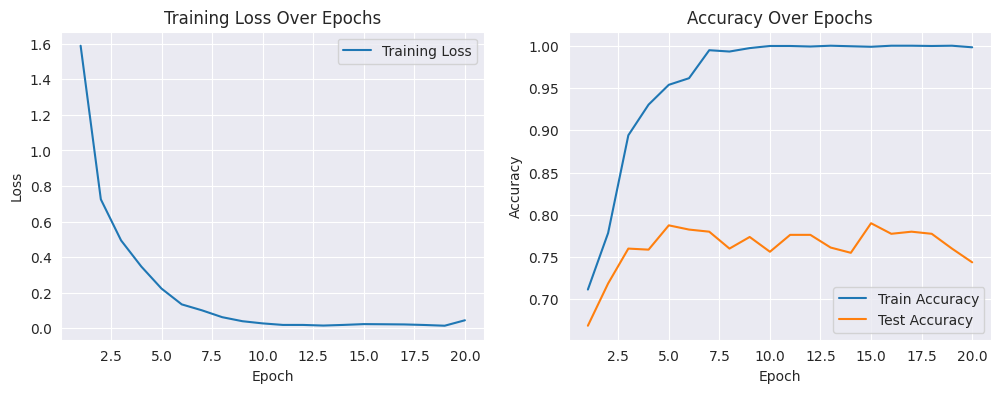

Final Train Accuracy: 99.81%
Final Test Accuracy: 74.38%


In [65]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accuracies, label='Train Accuracy')
plt.plot(range(1, num_epochs + 1), test_accuracies, label='Test Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Over Epochs")
plt.legend()
plt.show()

# Итоговые результаты
print(f"Final Train Accuracy: {train_accuracies[-1] * 100:.2f}%")
print(f"Final Test Accuracy: {test_accuracies[-1] * 100:.2f}%")

## Обратная связь
- [ ] Хочу получить обратную связь по решению